***Cell 1 — Import Libraries***

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb

%matplotlib inline

***Cell 2 — Load Dataset***

In [7]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
data = pd.read_csv("weatherAUS.csv")
data.head()

Saving weatherAUS.csv to weatherAUS.csv


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


***Cell 3 — Basic Info***

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  object 
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  object 
 10  WindDir3pm     138415 non-null  object 
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null

***Cell 4 — Describe***

In [9]:
data.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM
count,141556.000000,141871.000000,140787.000000,81350.000000,74377.000000,132923.000000,140845.000000,139563.000000,140419.000000,138583.000000,128179.000000,128212.000000,88536.000000,85099.000000,141289.000000,139467.000000,142193.000000
mean,12.186400,23.226784,2.349974,5.469824,7.624853,39.984292,14.001988,18.637576,68.843810,51.482606,1017.653758,1015.258204,4.437189,4.503167,16.987509,21.687235,2.360682
std,6.403283,7.117618,8.465173,4.188537,3.781525,13.588801,8.893337,8.803345,19.051293,20.797772,7.105476,7.036677,2.887016,2.720633,6.492838,6.937594,8.477969
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,0.000000
25%,7.600000,17.900000,0.000000,2.600000,4.900000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000
75%,16.800000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,371.000000


***Cell 5 — Shape***

In [ ]:
data.shape

(142193, 24)

***Cell 6 — Check Missing Values***

In [ ]:
data.isnull().sum()

,0
Date,0
Location,0
MinTemp,637
MaxTemp,322
Rainfall,1406
Evaporation,60843
Sunshine,67816
WindGustDir,9330
WindGustSpeed,9270
WindDir9am,10013


***Cell 7 — Handle Missing Values***

In [10]:
data = data.dropna(subset=['RainTomorrow'])
data = data.drop('Date', axis=1)
data = data.drop('RISK_MM', axis=1)   # target leakage column, remove it

numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']
Categorical columns: ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']


***Cell 8 — Impute Missing Values***

In [11]:
imp_mean = SimpleImputer(strategy='mean')
data[numeric_cols] = imp_mean.fit_transform(data[numeric_cols])

imp_mode = SimpleImputer(strategy='most_frequent')
data[categorical_cols] = imp_mode.fit_transform(data[categorical_cols])

data.isnull().sum().sum()

np.int64(0)

***Cell 9 — Correlation Heatmap***

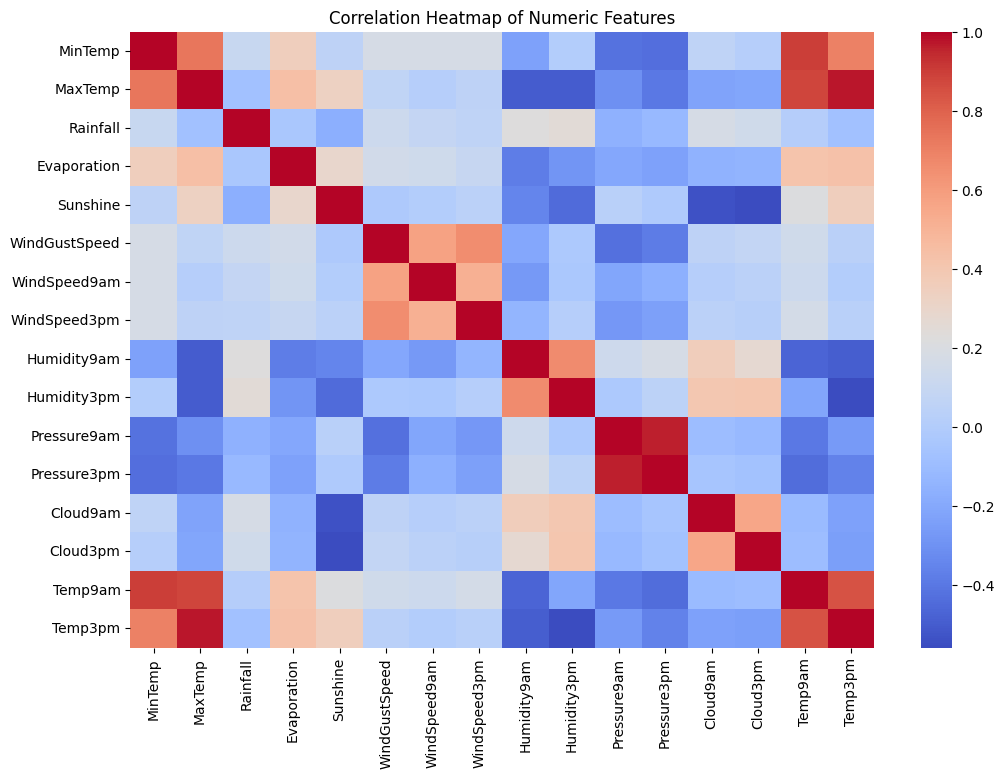

In [12]:
plt.figure(figsize=(12, 8))
sns.heatmap(data[numeric_cols].corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

***Cell 10 — RainTomorrow Distribution***

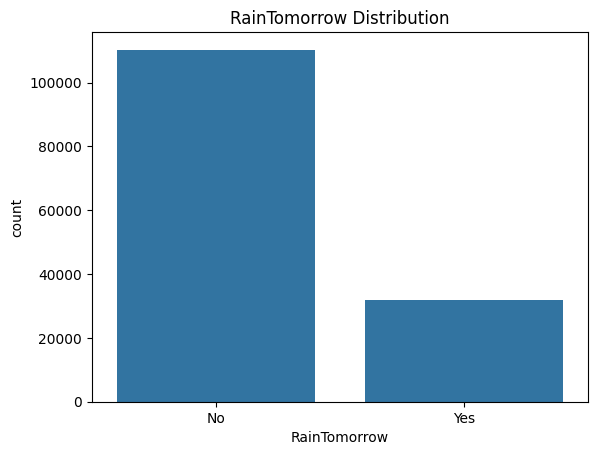

In [13]:
sns.countplot(x='RainTomorrow', data=data)
plt.title('RainTomorrow Distribution')
plt.show()

***Cell 11 — Humidity Distribution***

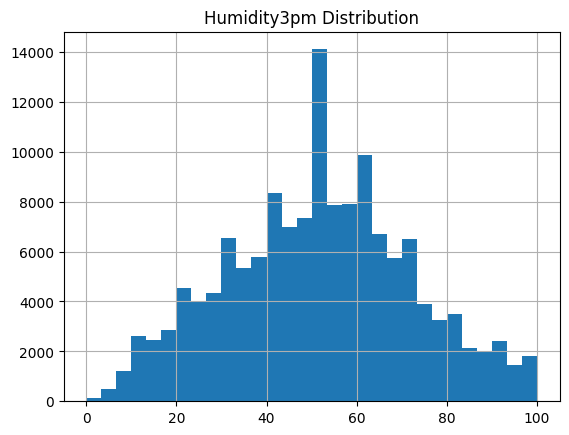

In [14]:
data['Humidity3pm'].hist(bins=30)
plt.title('Humidity3pm Distribution')
plt.show()

***Cell 12 — Encode Categorical Columns***

In [15]:
le = LabelEncoder()

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

data.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2,13.4,22.9,0.6,5.469824,7.624853,13,44.0,13,14,...,71.0,22.0,1007.7,1007.1,8.000000,4.503167,16.9,21.8,0,0
1,2,7.4,25.1,0.0,5.469824,7.624853,14,44.0,6,15,...,44.0,25.0,1010.6,1007.8,4.437189,4.503167,17.2,24.3,0,0
2,2,12.9,25.7,0.0,5.469824,7.624853,15,46.0,13,15,...,38.0,30.0,1007.6,1008.7,4.437189,2.000000,21.0,23.2,0,0
3,2,9.2,28.0,0.0,5.469824,7.624853,4,24.0,9,0,...,45.0,16.0,1017.6,1012.8,4.437189,4.503167,18.1,26.5,0,0
4,2,17.5,32.3,1.0,5.469824,7.624853,13,41.0,1,7,...,82.0,33.0,1010.8,1006.0,7.000000,8.000000,17.8,29.7,0,0


***Cell 13 — Split X and y***

In [16]:
y = data['RainTomorrow']
x = data.drop('RainTomorrow', axis=1)
feature_columns = x.columns

***Cell 14 — Feature Scaling***

In [17]:
sc = StandardScaler()
x_scaled = sc.fit_transform(x)
x = pd.DataFrame(x_scaled, columns=feature_columns)
x.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
0,-1.527004,0.189954,-0.045964,-0.207757,0.0,-6.495101e-16,1.052556,0.305648,1.328933,1.366277,...,0.614850,0.113891,-1.435935,-1.475456,-1.220966,1.563959,-4.219974e-16,-0.013521,0.016412,-0.532962
1,-1.527004,-0.749174,0.263480,-0.278989,0.0,-6.495101e-16,1.265582,0.305648,-0.221571,1.586236,...,0.385532,-1.312265,-1.289821,-1.045586,-1.116203,0.000000,-4.219974e-16,0.032832,0.380274,-0.532962
2,-1.527004,0.111694,0.347873,-0.278989,0.0,-6.495101e-16,1.478609,0.457874,1.328933,1.586236,...,0.844167,-1.629188,-1.046299,-1.490279,-0.981508,0.000000,-1.189322e+00,0.619963,0.220175,-0.532962
3,-1.527004,-0.467436,0.671383,-0.278989,0.0,-6.495101e-16,-0.864683,-1.216614,0.442931,-1.713146,...,-1.105034,-1.259444,-1.728162,-0.007969,-0.367897,0.000000,-4.219974e-16,0.171889,0.700472,-0.532962
4,-1.527004,0.831692,1.276205,-0.160269,0.0,-6.495101e-16,1.052556,0.077309,-1.329073,-0.173434,...,0.156214,0.694918,-0.900186,-1.015940,-1.385593,1.124991,1.661439e+00,0.125537,1.166215,-0.532962


***Cell 15 — Train-Test Split***

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (113754, 21)
Test shape: (28439, 21)


***Cell 16 — Initialize Models***

In [19]:
XGBoost   = xgb.XGBRFClassifier()
Rand_forest = RandomForestClassifier(n_estimators=100, max_depth=12, min_samples_leaf=5, random_state=42, n_jobs=-1)
svm       = SVC()
Dtree     = DecisionTreeClassifier()
GBM       = GradientBoostingClassifier()
log       = LogisticRegression(max_iter=1000)
knn       = KNeighborsClassifier()

/usr/local/lib/python3.13/dist-packages/xgboost/core.py:569: FutureWarning: `XGBRFClassifier` is deprecated and will be removed in a future release. The estimator is a thin wrapper over the boosting interface and does not implement a conventional random forest; features like early stopping are unsupported. Set `num_parallel_tree` along with `n_estimators=1` on the corresponding boosting estimator instead, or use a dedicated random forest implementation like those in `sklearn.ensemble`.
  return func(**kwargs)


***Cell 17 — Fit Models***

In [20]:
XGBoost.fit(x_train, y_train)
Rand_forest.fit(x_train, y_train)
svm.fit(x_train, y_train)
Dtree.fit(x_train, y_train)
GBM.fit(x_train, y_train)
log.fit(x_train, y_train)
knn.fit(x_train, y_train)

KNeighborsClassifier()

***Cell 18 — Train Accuracy***

In [23]:
p1 = XGBoost.predict(x_train)
p2 = Rand_forest.predict(x_train)
p3 = svm.predict(x_train)
p4 = Dtree.predict(x_train)
p5 = GBM.predict(x_train)
p6 = log.predict(x_train)
p7 = knn.predict(x_train)

print("xgboost:", metrics.accuracy_score(y_train, p1))
print("Rand_forest:", metrics.accuracy_score(y_train, p2))
print("svm:", metrics.accuracy_score(y_train, p3))
print("Dtree:", metrics.accuracy_score(y_train, p4))
print("GBM:", metrics.accuracy_score(y_train, p5))
print("log:", metrics.accuracy_score(y_train, p6))
print("knn:", metrics.accuracy_score(y_train, p7))

xgboost: 0.8464581465267156
Rand_forest: 0.8808833095979043
svm: 0.8618158482339082
Dtree: 0.9999648364013574
GBM: 0.8519260861156531
log: 0.8434428679431053
knn: 0.8800130105314978


***Cell 19 — Test Accuracy***

In [24]:
t1 = XGBoost.predict(x_test)
t2 = Rand_forest.predict(x_test)
t3 = svm.predict(x_test)
t4 = Dtree.predict(x_test)
t5 = GBM.predict(x_test)
t6 = log.predict(x_test)
t7 = knn.predict(x_test)

print("xgboost:", metrics.accuracy_score(y_test, t1))
print("Rand_forest:", metrics.accuracy_score(y_test, t2))
print("svm:", metrics.accuracy_score(y_test, t3))
print("Dtree:", metrics.accuracy_score(y_test, t4))
print("GBM:", metrics.accuracy_score(y_test, t5))
print("log:", metrics.accuracy_score(y_test, t6))
print("knn:", metrics.accuracy_score(y_test, t7))

xgboost: 0.8406062097823411
Rand_forest: 0.8488695101796828
svm: 0.8510847779457786
Dtree: 0.7849783747670452
GBM: 0.8473223390414572
log: 0.8396568093111572
knn: 0.832272583424171


***Cell 20 — Confusion Matrix***

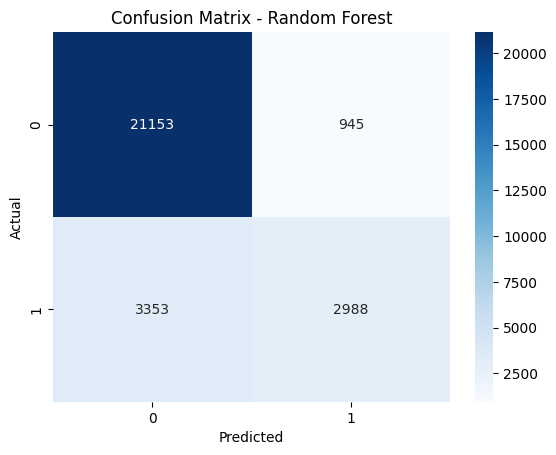

In [25]:
cm = metrics.confusion_matrix(y_test, t2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

***Cell 21 — ROC-AUC Curve***

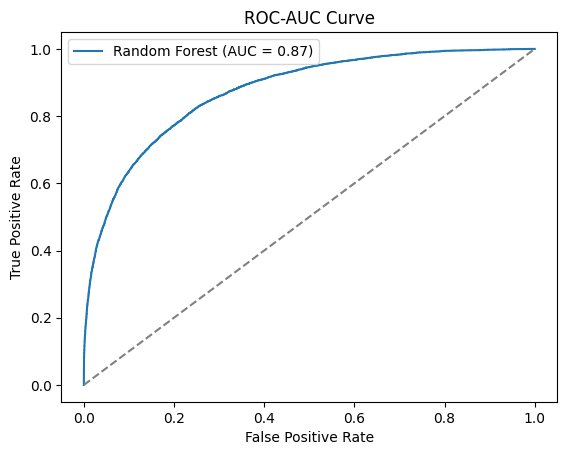

In [26]:
probs = Rand_forest.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = metrics.roc_curve(y_test, probs)
auc_score = metrics.roc_auc_score(y_test, probs)

plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend()
plt.show()

***Cell 22 — Save the Model***

In [27]:
pickle.dump(Rand_forest, open('rainfall.pkl', 'wb'))
pickle.dump(le, open('encoder.pkl', 'wb'))
pickle.dump(imp_mode, open('imputer.pkl', 'wb'))
pickle.dump(sc, open('scale.pkl', 'wb'))

print("Saved: rainfall.pkl, encoder.pkl, imputer.pkl, scale.pkl")

Saved: rainfall.pkl, encoder.pkl, imputer.pkl, scale.pkl
